# Combine local IQ models: hg19 5mc vs nothing

## Load models 

In [1]:
library(prego)
library(iceqream)
options(tidyverse.quiet = TRUE)
library(tidyverse)
library(purrr)
library(tgutil)
library(misha)
library(misha.ext)
library(glue)
library(here)
library(tgstat)

gsetroot(here("data/hg19"))
options(gmax.data.size = 1e+9)
source(here("code/model-utils.R"))

Loading required package: misha


Attaching package: ‘misha.ext’


The following object is masked from ‘package:misha’:

    gintervals.normalize


here() starts at /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper



In [2]:
cgd <- fread(here("output/cgd_hg19.tsv"))
rownames(cgd) <- cgd$id
add_feats <- readr::read_rds(here("output/add_feats_hg19_iq.rds"))
add_feats <- add_feats[rownames(cgd), ]

In [4]:
model_list <- load_models("_prego_10_motifs_no_add_oriented_hg19_k27_k4_vs_nothing", rename = FALSE)
rename_models(model_list, "_prego_10_motifs_no_add_oriented_hg19_k27_k4_vs_nothing", k27_column = "k27_l10")

→ Renaming full models

→ Renaming model "5"

→ Matching ELF1.2

→ Matched with "HOMER.ELF1", PSSM correlation = 0.61614978470275

→ Matching E2F1

→ Matched with "HOMER.E2F1", PSSM correlation = 0.604030851190623

→ Matching E2F4

→ Matched with "HOMER.E2F4", PSSM correlation = 0.73560201107329

→ Matching E2A_1

→ Matched with "HOMER.E2A_1", PSSM correlation = 0.807475699188978

→ Matching E2F6

→ Matched with "HOMER.E2F6", PSSM correlation = 0.711478025080279

→ Matching E_box_2

→ Matched with "HOMER.E_box_2", PSSM correlation = 0.790453042009084

→ Matching ELF1

→ Matched with "HOMER.ELF1", PSSM correlation = 0.635698209394963

→ Matching Sp1

→ Matched with "HOMER.Sp1", PSSM correlation = 0.54103344397268

→ Matching Atf1

→ Matched with "HOMER.Atf1", PSSM correlation = 0.643225748749834

→ Matching RUNX2

→ Matched with "HOMER.RUNX2", PSSM correlation = 0.543167208931269

→ Renaming model "3"

→ Matching Elk1

→ Matched with "HOMER.Elk1", PSSM correlation = 0.624783002482799

→

$`5`
NULL

$`3`
NULL

$`5_pad`
NULL

$`3_pad`
NULL

In [5]:
model_list <- load_models("_prego_10_motifs_no_add_oriented_hg19_k27_k4_vs_nothing", rename = TRUE)
models_auc <- calc_all_auc(model_list, cgd)

## Combined model

In [6]:
traj_model_comb <- combine_models.cv(model_list$full)
traj_model_comb_f <- combine_models.cv(model_list$filtered) %cache_rds% here("output/traj_model_comb_f_hg19_iq.rds")
traj_model_comb_f_inter <- combine_models.cv(model_list$filtered, add_interactions = T, add_feats = add_feats) %cache_rds% here("output/traj_model_comb_f_inter_hg19_iq.rds")

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-10

→ AUC train: 0.973383620425844, AUC test: 0.968230155605422. Number of motifs: 40

→ AUC train: 0.971409258138444, AUC test: 0.965786880889994. Number of motifs: 27

ℹ Adding interactions with threshold 0.01. Number of variables eligible for interactions: 20 out of 27

→ Number of interactions: 13

→ AUC train: 0.971373424278075, AUC test: 0.96574372719885. Number of motifs: 27



Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



$test_tss_auc
Area under the curve: 0.9127

$train_tss_auc
Area under the curve: 0.9252

$test_all_auc
Area under the curve: 0.9682

$train_all_auc
Area under the curve: 0.9734

$test_no_tss_auc
Area under the curve: 0.9594

$train_no_tss_auc
Area under the curve: 0.9646

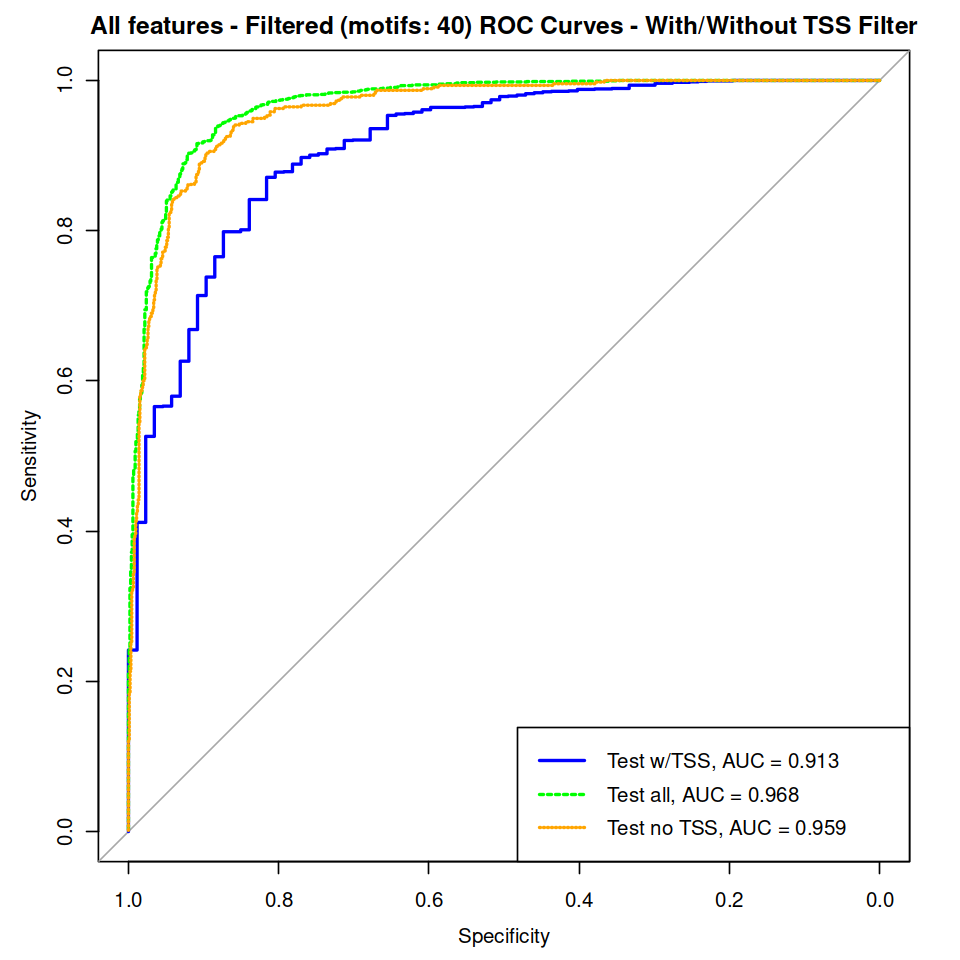

In [7]:
set_plot_size(8, 8)
plot_model_roc(traj_model_comb, cgd, glue("All features - Filtered (motifs: {length(traj_model_comb@motif_models)})"), plot_test_only = TRUE)

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



$test_tss_auc
Area under the curve: 0.9138

$train_tss_auc
Area under the curve: 0.9209

$test_all_auc
Area under the curve: 0.9658

$train_all_auc
Area under the curve: 0.9714

$test_no_tss_auc
Area under the curve: 0.9544

$train_no_tss_auc
Area under the curve: 0.9621

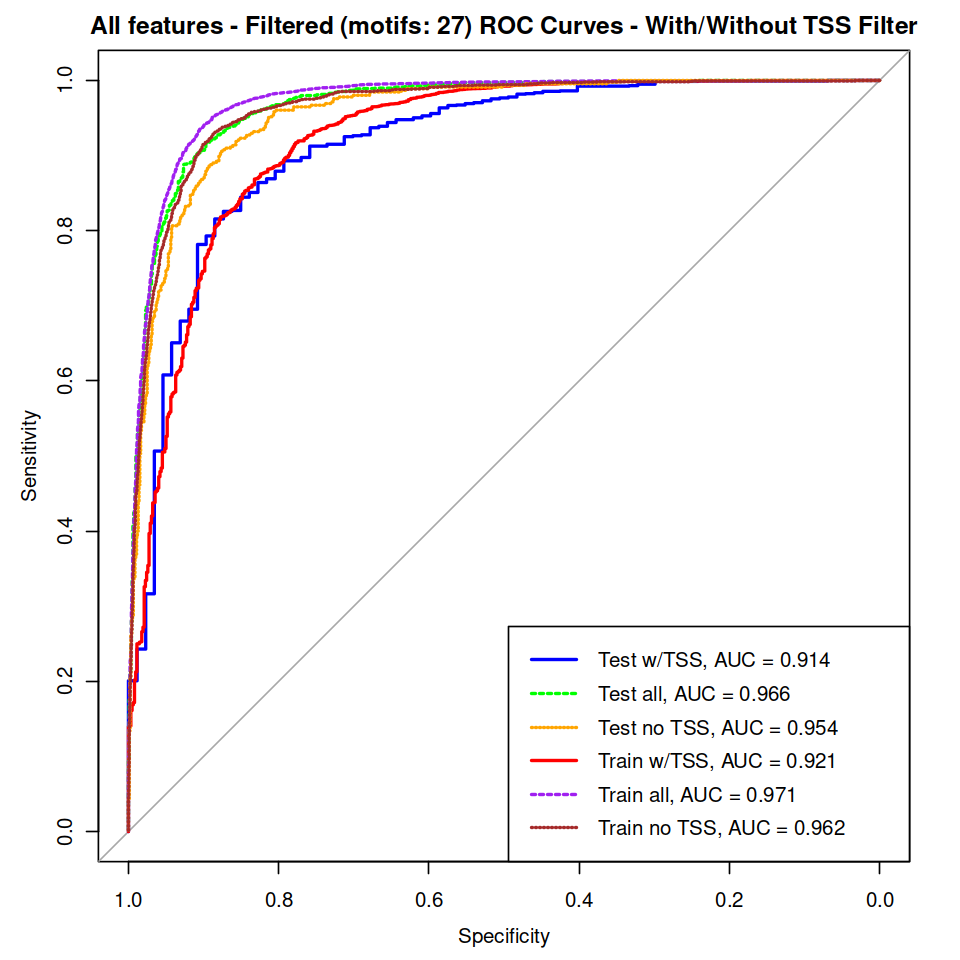

In [8]:
set_plot_size(8, 8)
plot_model_roc(traj_model_comb_f, cgd, glue("All features - Filtered (motifs: {length(traj_model_comb_f@motif_models)})"), plot_test_only = FALSE)

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



$test_tss_auc
Area under the curve: 0.9138

$train_tss_auc
Area under the curve: 0.9209

$test_all_auc
Area under the curve: 0.9658

$train_all_auc
Area under the curve: 0.9714

$test_no_tss_auc
Area under the curve: 0.9544

$train_no_tss_auc
Area under the curve: 0.9621

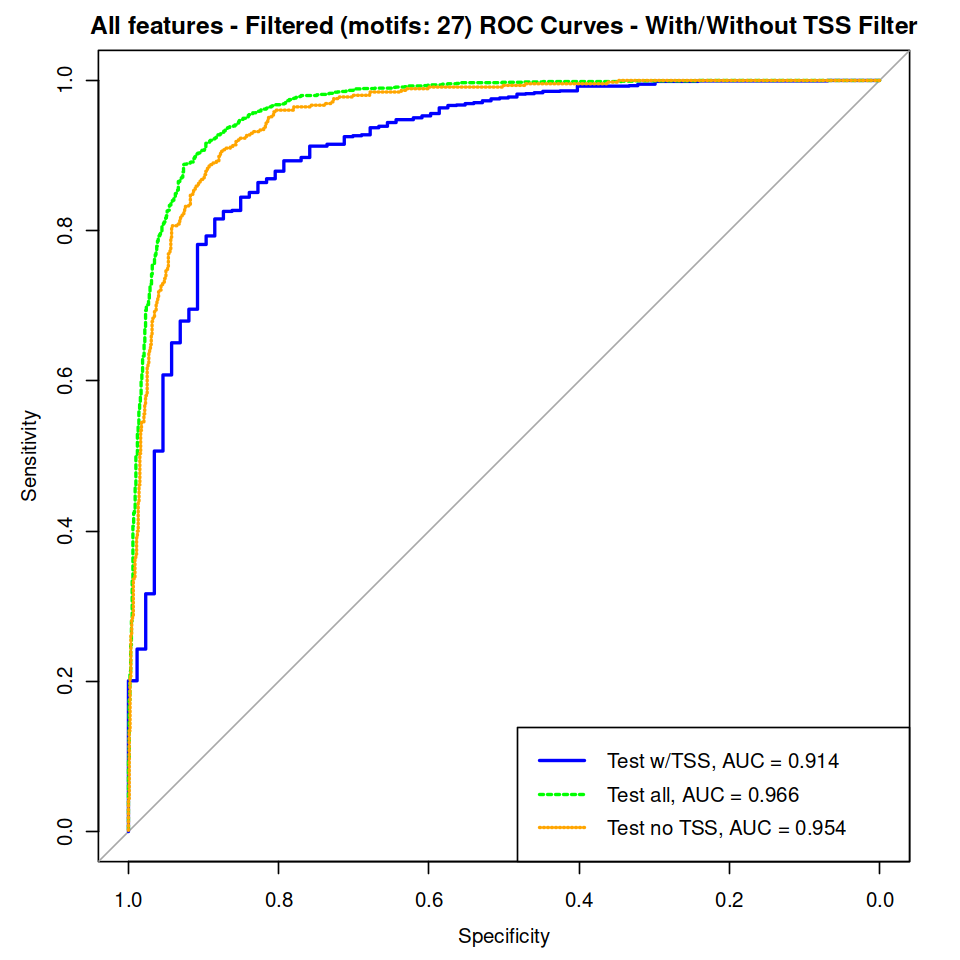

In [9]:
set_plot_size(8, 8)
plot_model_roc(traj_model_comb_f, cgd, glue("All features - Filtered (motifs: {length(traj_model_comb_f@motif_models)})"), plot_test_only = TRUE)

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



$test_tss_auc
Area under the curve: 0.9137

$train_tss_auc
Area under the curve: 0.9207

$test_all_auc
Area under the curve: 0.9657

$train_all_auc
Area under the curve: 0.9714

$test_no_tss_auc
Area under the curve: 0.9543

$train_no_tss_auc
Area under the curve: 0.9619

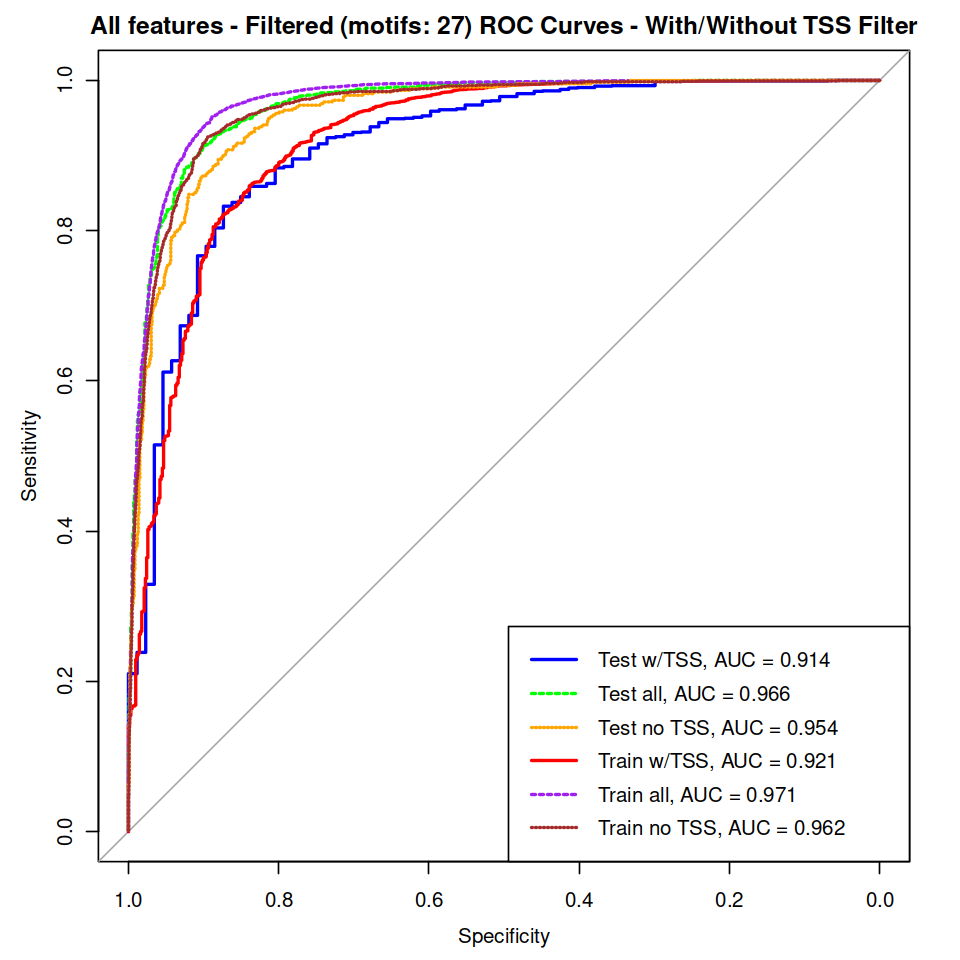

In [10]:
set_plot_size(8, 8)
plot_model_roc(traj_model_comb_f_inter, cgd, glue("All features - Filtered (motifs: {length(traj_model_comb_f_inter@motif_models)})"), plot_test_only = FALSE)

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



$test_tss_auc
Area under the curve: 0.9137

$train_tss_auc
Area under the curve: 0.9207

$test_all_auc
Area under the curve: 0.9657

$train_all_auc
Area under the curve: 0.9714

$test_no_tss_auc
Area under the curve: 0.9543

$train_no_tss_auc
Area under the curve: 0.9619

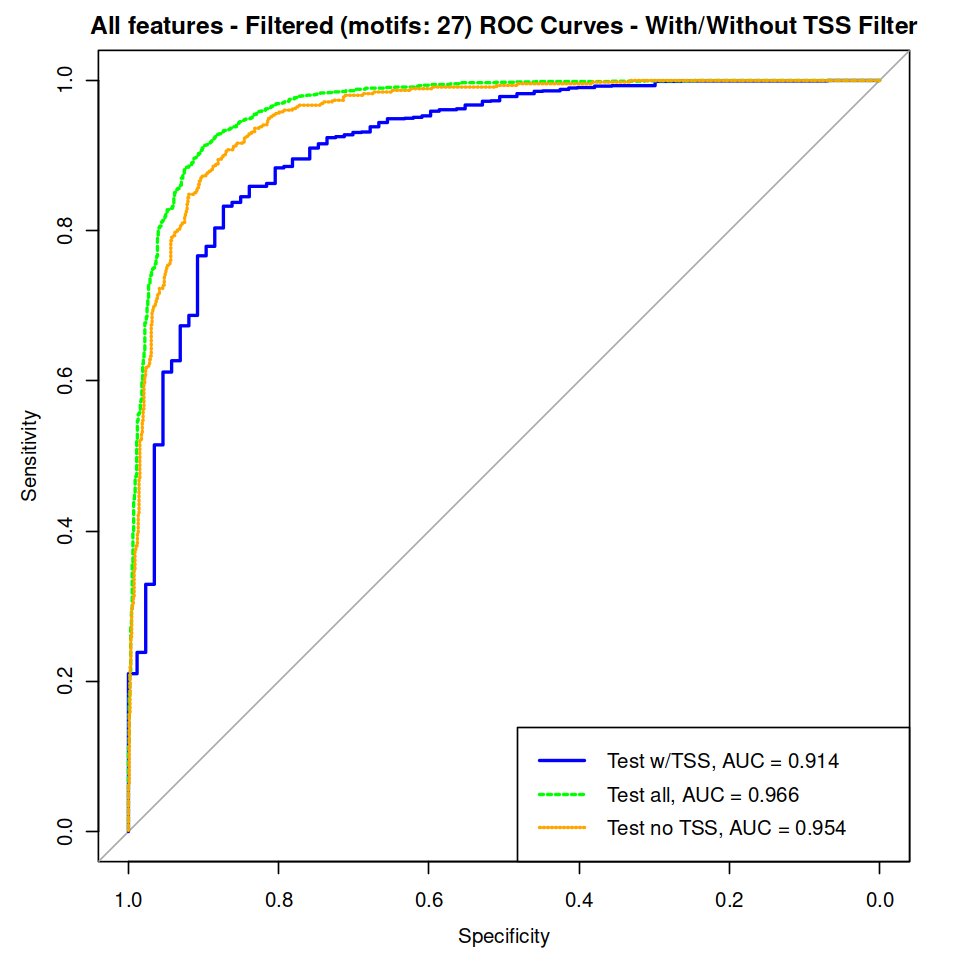

In [11]:
set_plot_size(8, 8)
plot_model_roc(traj_model_comb_f_inter, cgd, glue("All features - Filtered (motifs: {length(traj_model_comb_f_inter@motif_models)})"), plot_test_only = TRUE)

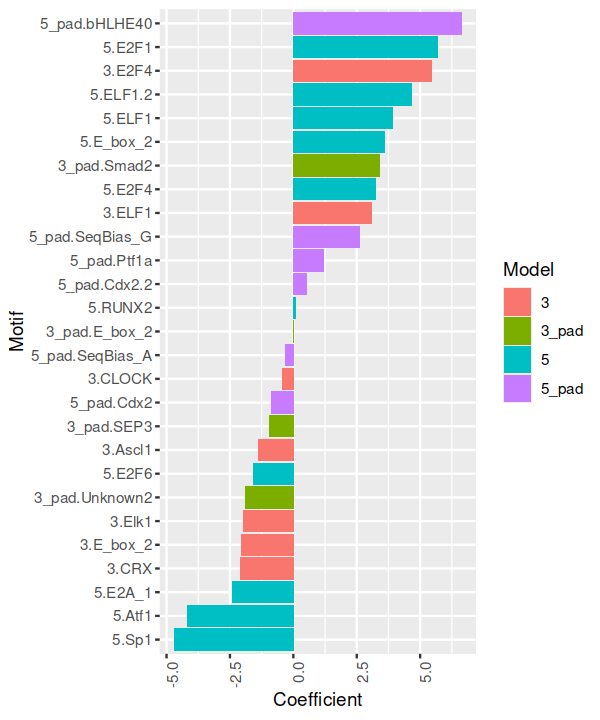

In [12]:
dinucs <- c("AA", "AC", "AG", "AT", "CA", "CC", "CG", "CT", "GA", "GC", "GG", "GT", "TA", "TC", "TG", "TT", "gc_content")
coefs <- traj_model_comb_f@coefs %>%
    filter(!gsub("^.+\\.", "", variable) %in% dinucs) %>%
    column_to_rownames("variable") %>%
    rowSums() %>%
    enframe("variable", "coef") %>%
    arrange(abs(coef)) %>%
    separate(variable, sep = "\\.", into = c("model", "motif"), extra = "merge", remove = FALSE)
set_plot_size(5, 6)
coefs %>%
    ggplot(aes(reorder(variable, coef), y = coef, fill = model)) +
    geom_col() +
    coord_flip() +
    theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
    labs(x = "Motif", y = "Coefficient", fill = "Model") 

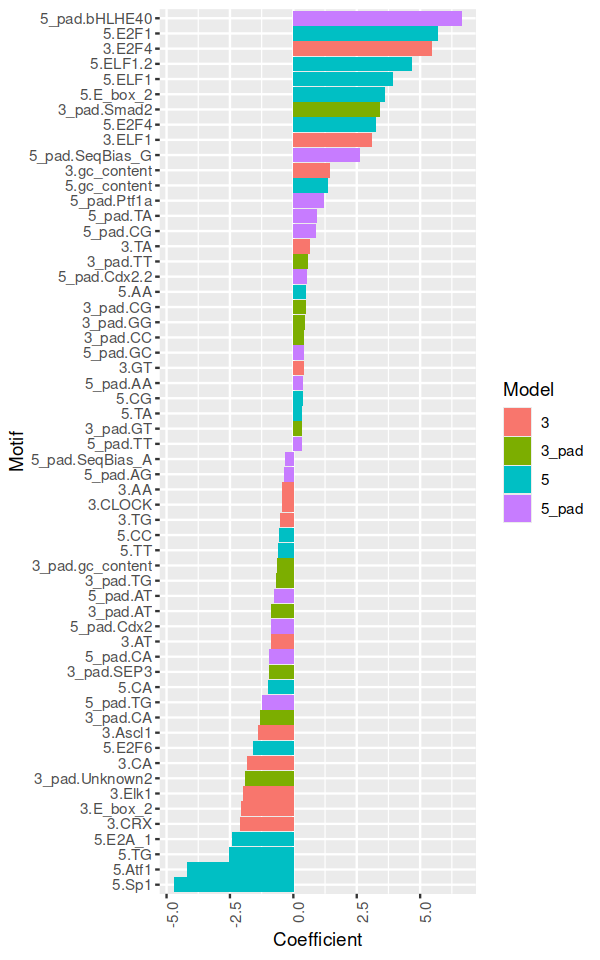

In [13]:
coefs <- traj_model_comb_f@coefs %>%    
    column_to_rownames("variable") %>%
    rowSums() %>%
    enframe("variable", "coef") %>%
    arrange(abs(coef)) %>%
    separate(variable, sep = "\\.", into = c("model", "motif"), extra = "merge", remove = FALSE)
set_plot_size(5, 8)
coefs %>%
    filter(abs(coef) >= 0.3) %>%
    ggplot(aes(reorder(variable, coef), y = coef, fill = model)) +
    geom_col() +    
    coord_flip() +
    theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
    labs(x = "Motif", y = "Coefficient", fill = "Model")


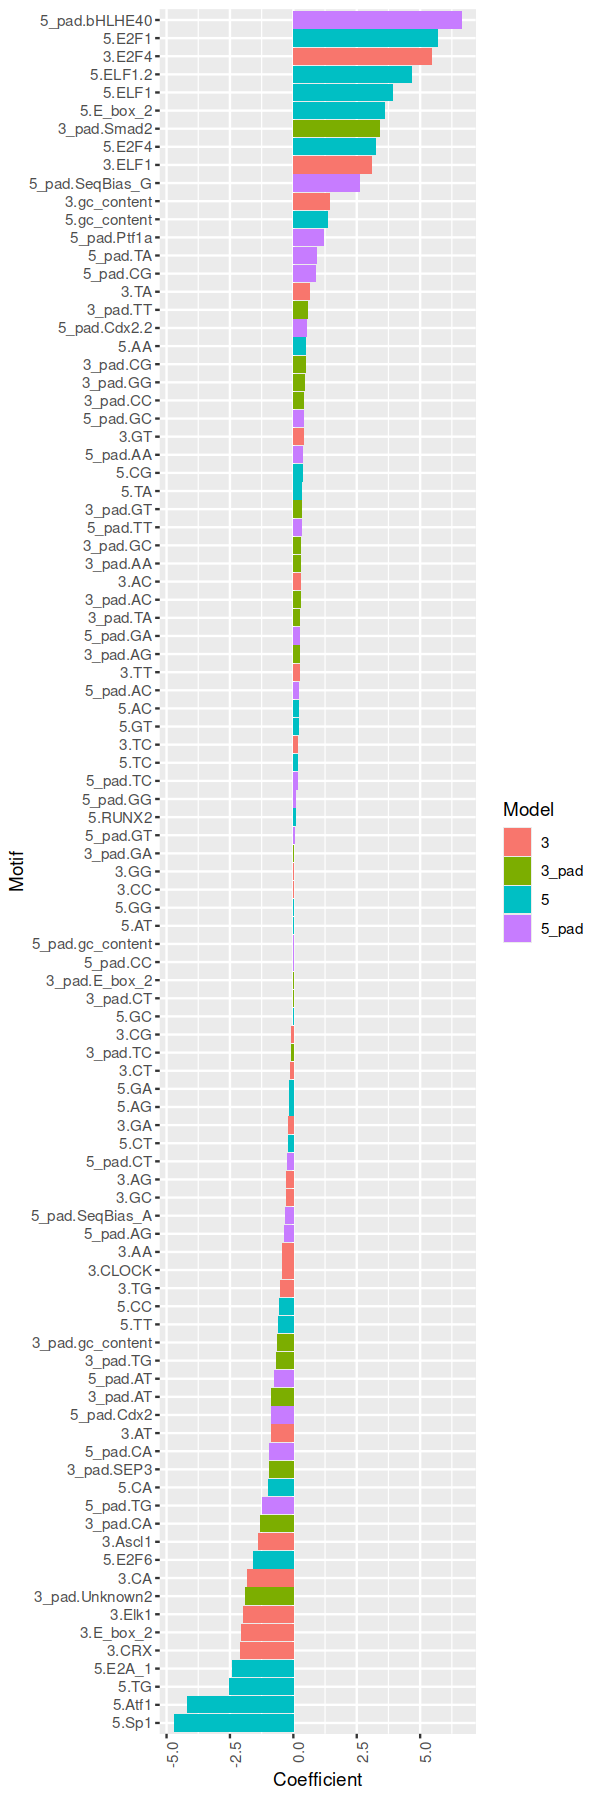

In [14]:
coefs <- traj_model_comb_f@coefs %>%
    column_to_rownames("variable") %>%
    rowSums() %>%
    enframe("variable", "coef") %>%
    arrange(abs(coef)) %>%
    separate(variable, sep = "\\.", into = c("model", "motif"), extra = "merge", remove = FALSE)
set_plot_size(5, 15)
coefs %>%
    ggplot(aes(reorder(variable, coef), y = coef, fill = model)) +
    geom_col() +
    coord_flip() +
    theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
    labs(x = "Motif", y = "Coefficient", fill = "Model")


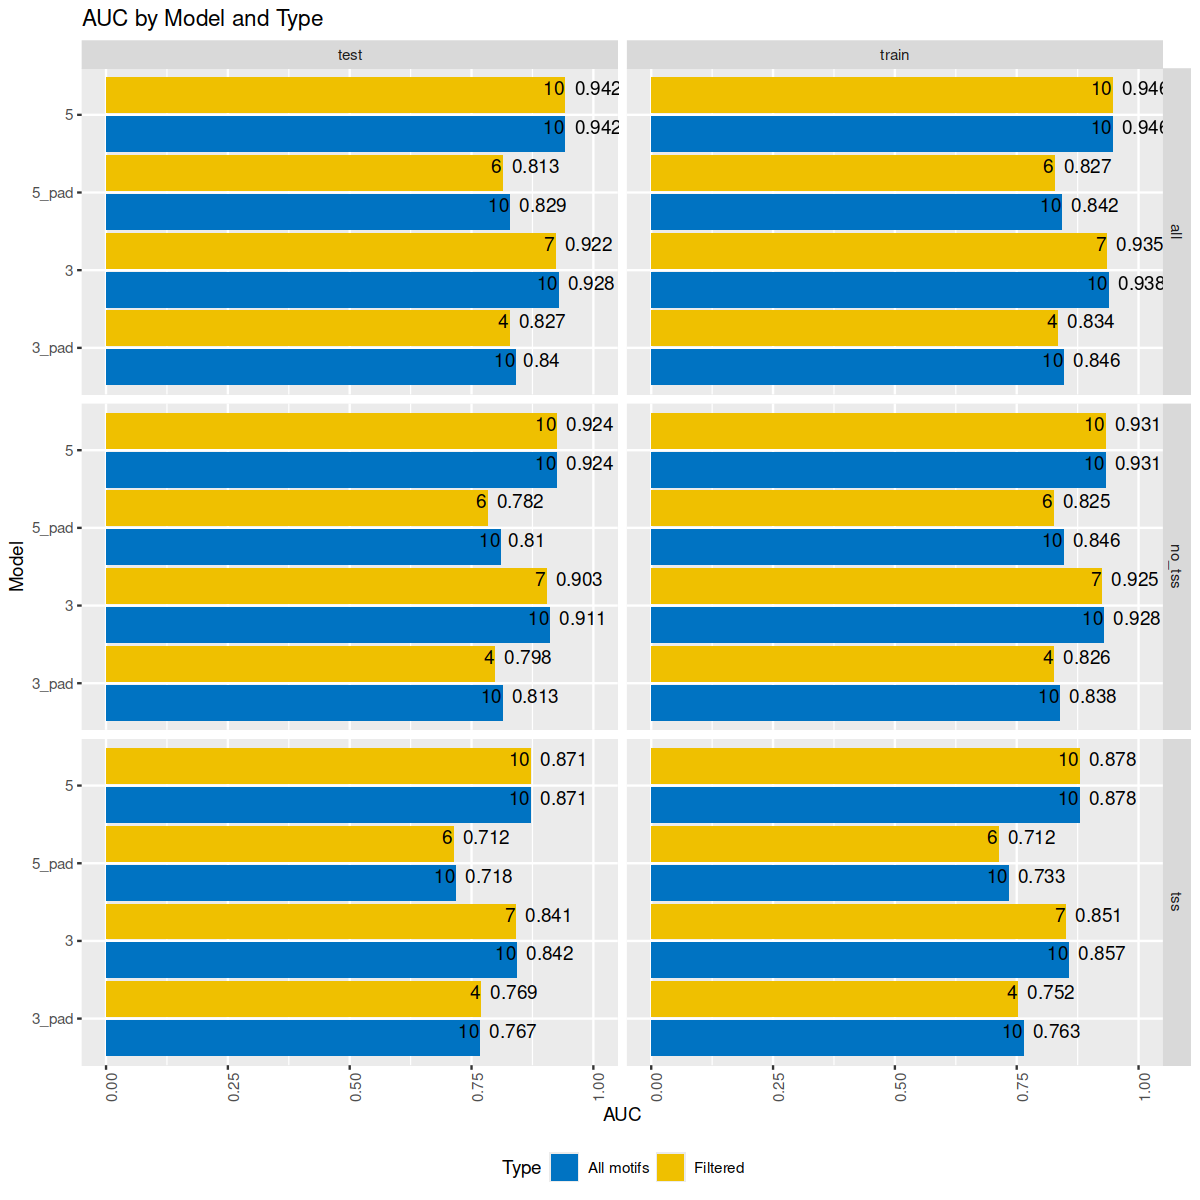

In [15]:
models_auc <- calc_all_auc(model_list, cgd)
plot_auc_by_type(models_auc)

In [16]:
preds_orient <- get_models_preds(model_list, cgd, comb_model = traj_model_comb, comb_model_f = traj_model_comb_f, k27_column = "k27_l10")
preds_tidy <- get_models_preds(model_list, cgd, tidy = TRUE, comb_model = traj_model_comb, comb_model_f = traj_model_comb_f, k27_column = "k27_l10")


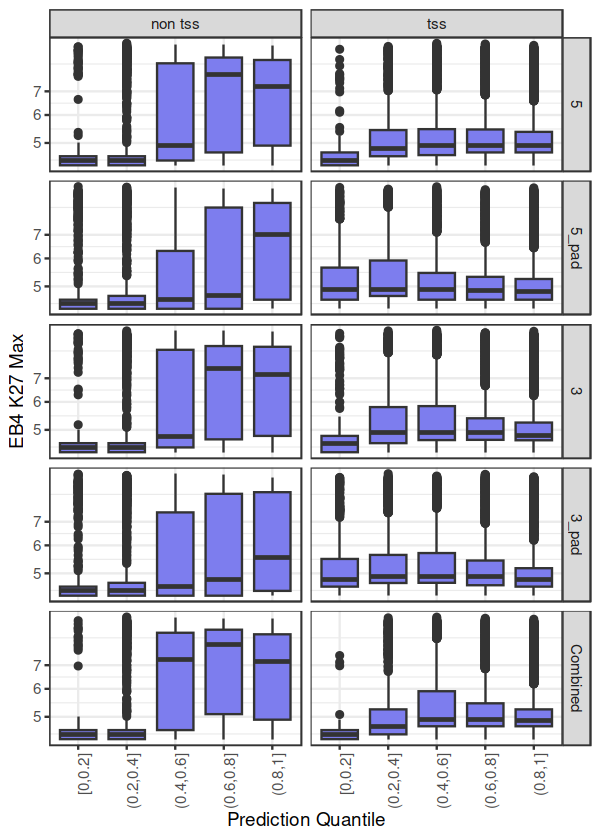

In [17]:
set_plot_size(5, 7)
plot_k27_pred_boxp(preds_tidy, k27_column = "k27_l10")

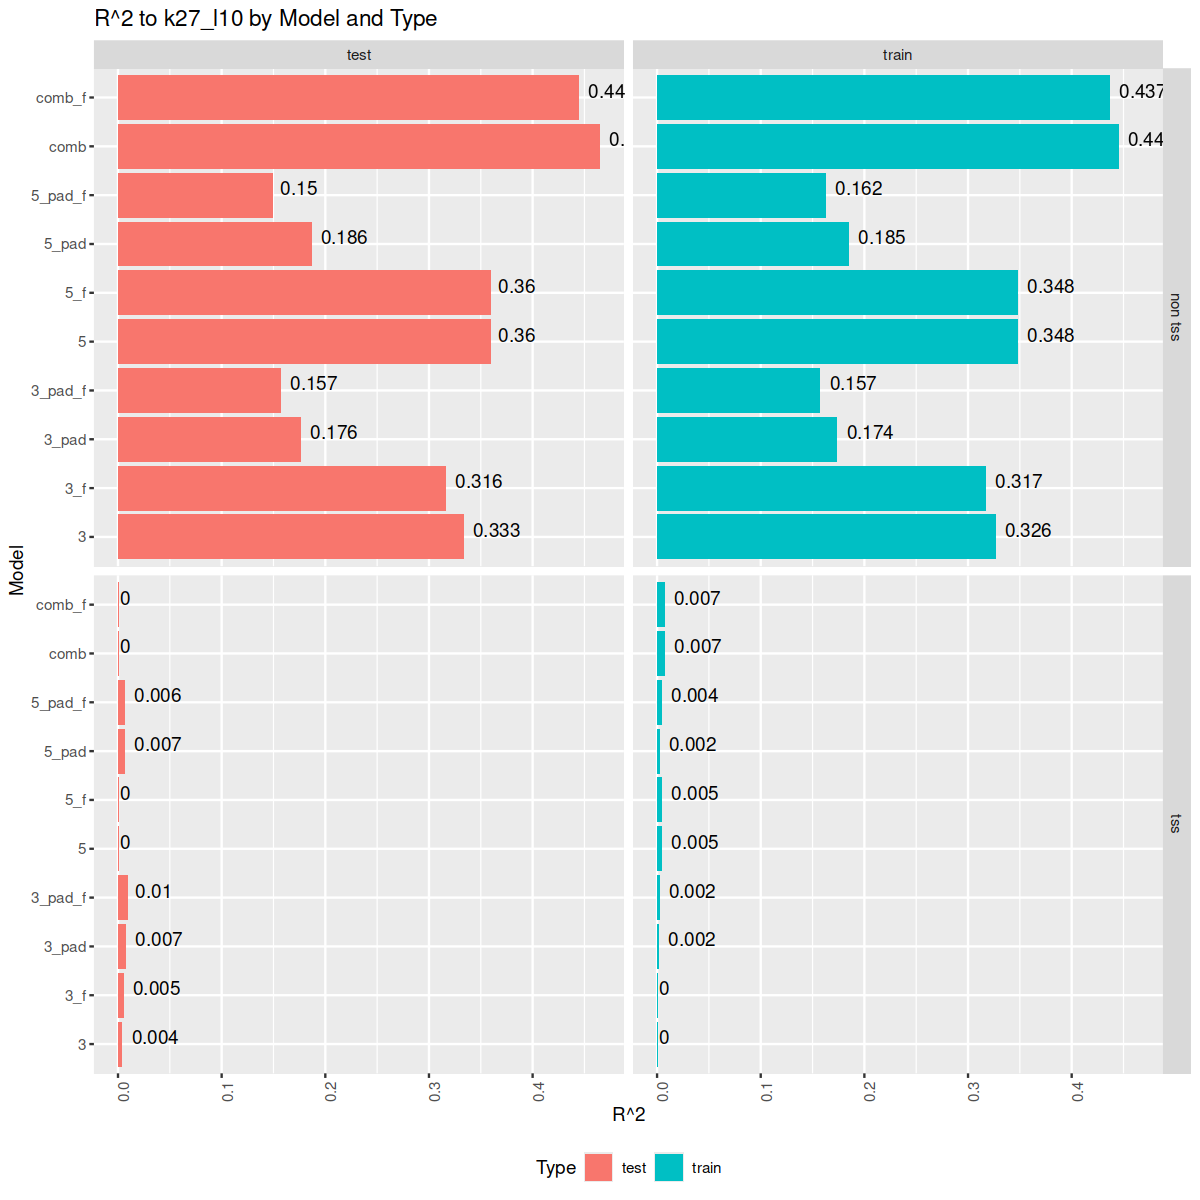

In [18]:
set_plot_size(10, 10)
plot_preds_r2(preds_orient, k27_column = "k27_l10")

In [23]:
dir.create(here("output/hg19-5mc-vs-nothing-report"))
file.copy(here("output/iq_5_prego_10_motifs_no_add_oriented_hg19_k27_k4_vs_nothing/iq_regression_filtered_model.pdf"), here("output/hg19-5mc-vs-nothing-report/5in_oriented.pdf"), overwrite = TRUE)
file.copy(here("output/iq_5_pad_prego_10_motifs_no_add_oriented_hg19_k27_k4_vs_nothing/iq_regression_filtered_model.pdf"), here("output/hg19-5mc-vs-nothing-report/5pad_oriented.pdf"), overwrite = TRUE)
file.copy(here("output/iq_3_prego_10_motifs_no_add_oriented_hg19_k27_k4_vs_nothing/iq_regression_filtered_model.pdf"), here("output/hg19-5mc-vs-nothing-report/3in_oriented.pdf"), overwrite = TRUE)
file.copy(here("output/iq_3_pad_prego_10_motifs_no_add_oriented_hg19_k27_k4_vs_nothing/iq_regression_filtered_model.pdf"), here("output/hg19-5mc-vs-nothing-report/3pad_oriented.pdf"), overwrite = TRUE)

Warning message in dir.create(here("output/hg19-5mc-vs-nothing-report")):
“'/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper/output/hg19-5mc-vs-nothing-report' already exists”


[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

## Predictions

In [24]:
cgd_all <- fread(here("output/cgd_hg19_iq.tsv"))
rownames(cgd_all) <- cgd_all$id

In [25]:
p <- combine_models.cv.predict(traj_model_comb_f, model_list$filtered, cgd)
p_all <- combine_models.cv.predict(traj_model_comb_f, model_list$filtered, cgd_all)
cgd <- cgd %>%
    mutate(pred = p[id])
cgd_all <- cgd_all %>%
    mutate(pred = p_all[id])
motif_db <- purrr::imap_dfr(traj_model_comb_f@motif_models, ~ .x$pssm %>% dplyr::mutate(motif = .y))
fwrite(motif_db, here("output/iq-hg19-5mc-vs-nothing-motif_db.tsv"), sep = "\t")
fwrite(cgd_all, here("output/iq-hg19-5mc-vs-nothing-model_preds.tsv"), sep = "\t")

→ Calculating energies

ℹ Extracting sequences...

ℹ Computing motif energies for 18181 intervals and 18181 normalization intervals

ℹ Extracting sequences...

ℹ Computing motif energies for 18181 intervals and 18181 normalization intervals

ℹ Extracting sequences...

ℹ Computing motif energies for 18181 intervals and 18181 normalization intervals

ℹ Extracting sequences...

ℹ Computing motif energies for 18181 intervals and 18181 normalization intervals

→ Creating sequence features

→ Calculating energies

ℹ Extracting sequences...

ℹ Computing motif energies for 34153 intervals and 18181 normalization intervals

ℹ Extracting sequences...

ℹ Computing motif energies for 34153 intervals and 18181 normalization intervals

ℹ Extracting sequences...

ℹ Computing motif energies for 34153 intervals and 34153 normalization intervals

ℹ Extracting sequences...

ℹ Computing motif energies for 34153 intervals and 18181 normalization intervals

→ Creating sequence features

